In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_tavily import TavilySearch

tool = TavilySearch(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

def web_search(state: AgentState):
    query = state["query"]
    results = tool.invoke(query)
    print(f'web search results == {results}')
    return {'context': results}

In [4]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

client = Client()
llm = ChatOpenAI(model="gpt-4o")

generate_prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

def web_generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
basic_llm = ChatOpenAI(model="gpt-4o-mini")

def basic_generate(state: AgentState):
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()
    response = basic_llm_chain.invoke(query)
    return {'answer': response}

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2024.
if you think the question is simple enough use 'llm'
if you think you need to search the web to answer the question use 'web_search'
"""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatOpenAI(model="gpt-4o-mini")
structured_router_llm = router_llm.with_structured_output(Route)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    print(f'router route == {route}')
    print(f'route.target == {route.target}')
    return route.target

In [7]:
from income_tax_graph import graph as income_tax_subgraph

graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

answer == {'answer': '연봉 5천만원인 거주자의 소득세는 624만원입니다.'}


In [8]:
from langgraph.graph import START, END
graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'income_tax_agent',
        'llm': 'basic_generate',
        'web_search': 'web_search',
    }
)
graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('income_tax_agent', END)

In [9]:
graph = graph_builder.compile()

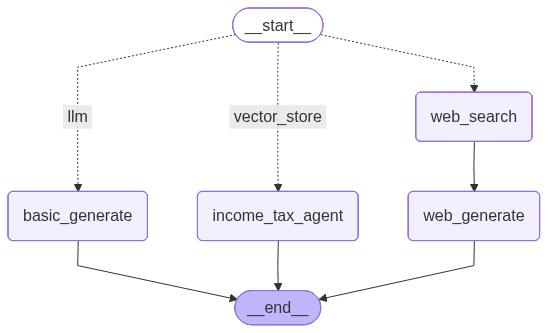

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
initial_state = {'query': '대한민국의 수도는 어디인가요?'}
graph.invoke(initial_state)

router route == target='llm'
route.target == llm


{'query': '대한민국의 수도는 어디인가요?', 'answer': '대한민국의 수도는 서울입니다.'}

In [12]:
initial_state = {'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

router route == target='vector_store'
route.target == vector_store
context == [Document(id='dae5d00d-ab30-4ff3-9434-63243526f05a', metadata={'source': './documents/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>\n  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. \n[개정 2014. 1. 1.]\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제2절 세액의 계산 <개정 2009. 12. 31.>\n제1관 세율 <개정 2009. 12. 31.>\n제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017

{'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='dae5d00d-ab30-4ff3-9434-63243526f05a', metadata={'source': './documents/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>\n  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. \n[개정 2014. 1. 1.]\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제2절 세액의 계산 <개정 2009. 12. 31.>\n제1관 세율 <개정 2009. 12. 31.>\n제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2

In [13]:
initial_state = {'query': '역삼 맛집을 추천해주세요'}
graph.invoke(initial_state)

router route == target='web_search'
route.target == web_search
web search results == {'query': '역삼 맛집을 추천해주세요', 'follow_up_questions': None, 'answer': '역삼 맛집으로 신동궁 감자탕 역삼본점이 유명하며, 떡도리탕과 위트앤미트도 추천됩니다. 고갯마루집은 닭볶음탕으로 인기가 많습니다. 보슬보슬은 건강식 김밥으로 알려져 있습니다.', 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNDEwMTVfMjgz/MDAxNzI4OTc1MzQ0MTA0.b7OoL30rv8ZXcoNCCwHGoNcww1BvlkoYor6ZNdO36pcg.yIE47UUiIP5lyQ6mHrsX_zMVEZGV6J5oZ5WPddvLdPwg.JPEG/%EC%A0%9C%EB%AA%A9%EC%9D%84_%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94_-004_(2).jpg?type=w800', 'https://mblogthumb-phinf.pstatic.net/MjAyNjAzMjlfMjA5/MDAxNzc0NzgwNzYzNTM0.PineCAoAodp-TWk08AMf0CrdD8yy7GTdUNjV9H7NUgYg.WgwapPS5KDp13IbVjcZaR1mpOIyOX-yQGJ_K1fxH5SMg.PNG/%EC%A0%9C%EB%AA%A9%EC%9D%84_%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94%EF%BC%8D177.png?type=w800', 'https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FAQUTn%2FbtrXJgc8LC6%2FAAAAAAAAAAAAAAAAAAAAAPKvBQWDH_JtNsy3DiV4XGVXRYXp3gRHNq

{'query': '역삼 맛집을 추천해주세요',
 'context': {'query': '역삼 맛집을 추천해주세요',
  'follow_up_questions': None,
  'answer': '역삼 맛집으로 신동궁 감자탕 역삼본점이 유명하며, 떡도리탕과 위트앤미트도 추천됩니다. 고갯마루집은 닭볶음탕으로 인기가 많습니다. 보슬보슬은 건강식 김밥으로 알려져 있습니다.',
  'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNDEwMTVfMjgz/MDAxNzI4OTc1MzQ0MTA0.b7OoL30rv8ZXcoNCCwHGoNcww1BvlkoYor6ZNdO36pcg.yIE47UUiIP5lyQ6mHrsX_zMVEZGV6J5oZ5WPddvLdPwg.JPEG/%EC%A0%9C%EB%AA%A9%EC%9D%84_%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94_-004_(2).jpg?type=w800',
   'https://mblogthumb-phinf.pstatic.net/MjAyNjAzMjlfMjA5/MDAxNzc0NzgwNzYzNTM0.PineCAoAodp-TWk08AMf0CrdD8yy7GTdUNjV9H7NUgYg.WgwapPS5KDp13IbVjcZaR1mpOIyOX-yQGJ_K1fxH5SMg.PNG/%EC%A0%9C%EB%AA%A9%EC%9D%84_%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94%EF%BC%8D177.png?type=w800',
   'https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FAQUTn%2FbtrXJgc8LC6%2FAAAAAAAAAAAAAAAAAAAAAPKvBQWDH_JtNsy3DiV4XGVXRYXp3gRHNqdBycDfd2T0%2Fimg.jpg%3Fcredential%